# Eight Tests, Eight No-Gos: Screening Online Attention as a Stock Signal

### Does publicly available online attention lead weekly stock returns?

**The Business Question:** an investment advisory firm is considering building a tool around online attention data. Before committing budget, they want to know whether there is a signal worth chasing.

**Findings:** Recommendation: Do not build. All eight pre-registered tests (4 stocks × 2 attention sources) fall below the action bar.

This is a correlation and lag screening exercise producing a go / investigate / no-go decision. It is not a prediction model or investment advice.

The bar was set before any data was seen. A one-week lag and a 0.20 action threshold were selected in advance (see Section 6).

## Section 1 Setup

Library imports and display settings.


In [4]:
#Section 1: Setup
!pip -q install pytrends
!pip -q install streamlit
import time
import warnings

import pandas as pd
import numpy as np
from scipy import stats

from pytrends.request import TrendReq
import yfinance as yf
import requests

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

## Section 2: Data Collection

Two attention sources are used. They capture intent and demand versus consumption and engagement. Evidence of their agreement is stronger evidence than either alone. Section 6 shows they do not always agree, which is itself a finding.

- **Yahoo Finance** (yfinance)
- **Google Trends** (pytrends)
- **Wikipedia Page Views** (Wiki REST API)

**Ticker vs. Company Name**: Correlations between ticker and company-name searches differed slightly, suggesting that the two capture different search behaviour. Ticker searches were used in the main analysis because they are more likely to reflect investor interest. The META/Meta comparison could not be evaluated because Google Trends is case-insensitive.

**Auto-Adjust**: It keeps consistency in NVDA's data, taking account the June 2024 10-1 stock split.


**This section is for reference only.** *The raw data in /data is the canonical source. Skip to Section 3 to reproduce the analysis. Google Trends data is normalized based on the terms included in each request, so downloading it again will not produce the exact same values.*

In [5]:
#Section 2: Data Collection
#Google Trends
pytrends = TrendReq(hl='en-US', tz=0)
TICKERS = ['TSLA','NVDA','META','JPM']
START_DATE = '2022-01-01'
END_DATE = '2024-12-31'
END_DATE_YF = '2025-01-01'
TIMEFRAME = f"{START_DATE} {END_DATE}"

print(f"Stocks: {TICKERS}")
print(f"Timeframe string: {TIMEFRAME}")

##Comparison: Ticker v Company Name #1 TESLA
def get_trends_series(keyword, timeframe, geo='', sleep=2):
  try:
    pytrends.build_payload([keyword],timeframe=timeframe,geo=geo)
    time.sleep(sleep)

    df = pytrends.interest_over_time()

    if df.empty:
      print(f"Empty Series Returned for '{keyword}.May be rate-limited or low volume term")
      return None

    if 'isPartial' in df.columns:
      df=df.drop(columns=['isPartial'])

    series= df[keyword]

    return series

  except Exception as e:
      print(f"Error pulling '{keyword}': {e}")
      return None

print("\nComparison: Ticker v Company Name (TSLA)")
time.sleep(3)

tsla_ticker = get_trends_series('TSLA', TIMEFRAME)
time.sleep(5)
tsla_name = get_trends_series('Tesla', TIMEFRAME)

if tsla_ticker is not None and tsla_name is not None:
  correlation_check=tsla_ticker.corr(tsla_name)
  print(f"Correlation between 'TSLA' and 'Tesla' series: {correlation_check:.3f}")

  if correlation_check > 0.95:
    print(f"Series are nearly identical (r>0.95). Using ticker symbol.")
  else:
    print(f"Series differ materially (r={correlation_check:.3f}).")
else:
  print("Could not complete comparison (check rate limiting)")

##Comparison: Ticker v Company Name #2 NVIDIA
print("\nComparison: Ticker v Company Name (NVDA)")
time.sleep(3)

nvda_ticker=get_trends_series('NVDA', TIMEFRAME)
time.sleep(5)
nvda_name=get_trends_series('Nvidia', TIMEFRAME)

if nvda_ticker is not None and nvda_name is not None:
  correlation_check=nvda_ticker.corr(nvda_name)
  print(f"Correlation between 'NVDA' and 'Nvidia' series: {correlation_check:.3f}")

  if correlation_check > 0.95:
    print(f"Series are nearly identical (r>0.95). Using ticker symbol.")
  else:
    print(f"Series differ materially (r={correlation_check:.3f}).")
else:
  print("Could not complete comparison (check rate limiting)")

##Ticker v company name test #3 META
print("\nComparison: Ticker v Company Name (META)")
time.sleep(3)

meta_ticker=get_trends_series('META', TIMEFRAME)
time.sleep(5)
meta_name=get_trends_series('Meta', TIMEFRAME)

if meta_ticker is not None and meta_name is not None:
  correlation_check=meta_ticker.corr(meta_name)
  print(f"Correlation between 'META' and 'Meta' series: {correlation_check:.3f}")
  print("N/A — 'META' and 'Meta' are the same search term to Google Trends "
        "(case-insensitive). This is a series compared to itself, not a real test.")
else:
  print("Could not complete comparison (check rate limiting)")

##Ticker v company name test #4 JPM
print("\nComparison: Ticker v Company Name (JPMorgan)")
time.sleep(3)

jpm_ticker=get_trends_series('JPM', TIMEFRAME)
time.sleep(5)
jpm_name=get_trends_series('JPMorgan', TIMEFRAME)

if jpm_ticker is not None and jpm_name is not None:
  correlation_check=jpm_ticker.corr(jpm_name)
  print(f"Correlation between 'JPM' and 'JPMorgan' series: {correlation_check:.3f}")

  if correlation_check > 0.95:
    print(f"Series are nearly identical (r>0.95). Using ticker symbol.")
  else:
    print(f"Series differ materially (r={correlation_check:.3f}).")
else:
  print("Could not complete comparison (check rate limiting)")

##Flat Series Check
def check_flat_series(series, keyword, threshold=5):
  if series is None:
    print(f"Fail:'{keyword}' series is None (collection failed)")
    return False

  pct_above_threshold=(series>threshold).mean()*100

  if pct_above_threshold < 10:
    print(f"Fail:'{keyword} {pct_above_threshold:.0f}% of values above {threshold}")
    return False
  else:
    print(f"Pass:'{keyword} {pct_above_threshold:.0f}% of values above {threshold}")
    return True

##Data collection loop
print("\nCollecting Google Trends data for tickers")
trends_data = {
    'TSLA': tsla_ticker,
    'NVDA': nvda_ticker,
    'META': meta_ticker,
    'JPM':  jpm_ticker,
}
flat_series_results = {}
for ticker in TICKERS:
  flat_series_results[ticker] = check_flat_series(trends_data[ticker], ticker)
  time.sleep(10)

print("\nFlat Series Check Summary")
for ticker, passed in flat_series_results.items():
  status = "PASS" if passed else "FAIL - Review Required"
  print(f"  {ticker}: {status}")

failed_tickers = [t for t,p in flat_series_results.items() if not p]
if failed_tickers:
  print(f"\nWarning: {failed_tickers} failed flat series check")
else:
  print("\nAll tickers passed flat series check.")

###Data Frame
valid_tickers = [t for t, p in flat_series_results.items() if p]

trends_df = pd.DataFrame(
    {ticker: trends_data[ticker] for ticker in valid_tickers}
)

trends_df.index = pd.to_datetime(trends_df.index)
trends_df.index.name = 'date'

print(f"\nGoogle Trends DataFrame shape: {trends_df.shape}")
print(f"Data range:{trends_df.index.min()} to {trends_df.index.max()}")
print(f"\nFirst 5 rows:\n {trends_df.head()}")
print(f"\nMissing values:\n{trends_df.isnull().sum()}")

###Raw data to CSV
trends_df.to_csv('trends_raw.csv')
if IN_COLAB: files.download('trends_raw.csv')

print(f"\nCSV saved. Canonical dataset, do not re-query pytrends.")
print("\nQuery Parameters")
print(f"Search terms: {valid_tickers}")
print(f"Timeframe: {TIMEFRAME}")
print(f"Geography: worldwide (geo='')")
print(f"Timezone: UTC (tz=0)")

#Yahoo Finance (yfinance)
print("Collecting stock price data from Yahoo Finance")

prices_raw = yf.download(
    tickers = TICKERS,
    start = START_DATE,
    end = END_DATE_YF,
    auto_adjust = True,
    progress = True
)

prices_close = prices_raw['Close'].copy()
prices_close.index = pd.to_datetime(prices_close.index)
prices_close.index.name = 'date'

print(f"\nRaw download shape: {prices_raw.shape}")
print(f"Column levels: {prices_raw.columns.names}")
print(f"\nAvailable metrics: {prices_raw.columns.get_level_values(0).unique(0).tolist()}")

for ticker in TICKERS:
  if ticker in prices_close.columns:
    null_pct = prices_close[ticker].isnull().mean()*100
    print(f"  {ticker}: {len(prices_close[ticker].dropna())} observations, "
              f"{null_pct:.1f}% null")
  else:
    print(f"Warning: {ticker} not found in download results")

prices_close.to_csv('prices_raw.csv')
if IN_COLAB: files.download('prices_raw.csv')


#Wikipedia (REST API)
WIKI_ARTICLES = {
    'TSLA': 'Tesla,_Inc.',
    'NVDA': 'Nvidia',
    'META': 'Meta_Platforms',
    'JPM':  'JPMorgan_Chase'
}

WIKI_BASE = (
    "https://wikimedia.org/api/rest_v1/metrics/pageviews/"
    "per-article/en.wikipedia/all-access/all-agents/"
    "{article}/daily/{start}/{end}"
)

WIKI_START = START_DATE.replace('-', '') + '00'
WIKI_END = END_DATE.replace('-', '') + '00'

def get_wikipedia_views(article_name, start, end):
    url = WIKI_BASE.format(article=article_name, start=start, end=end)

    try:
        response = requests.get(url, headers={'User-Agent': 'portfolio-project/1.0'})

        if response.status_code == 200:
            data = response.json()
            items = data.get('items', [])

            if not items:
                print(f"Warning: No items returned for '{article_name}'")
                return None

            dates = pd.to_datetime(
                [item['timestamp'][:8] for item in items],
                format='%Y%m%d'
            )

            views = [item['views'] for item in items]
            series = pd.Series(views, index=dates, name=article_name)
            print(f"'{article_name}': {len(series)} daily observations, "
                  f"avg {series.mean():.0f} views/day")
            return series

        elif response.status_code == 404:
            print(f"Error 404: Article '{article_name}' not found")
            return None

        else:
            print(f"Error {response.status_code}: {response.text[:200]}")
            return None

    except Exception as e:
        print(f"Error: {e}")
        return None

print("Collecting Wiki page views")
wiki_data = {}
for ticker, article in WIKI_ARTICLES.items():
  series = get_wikipedia_views(article, WIKI_START, WIKI_END)
  wiki_data[ticker] = series
  time.sleep(1)

###Data Frame and CSV save
valid_wiki = {t: s for t, s in wiki_data.items() if s is not None}

wiki_df = pd.DataFrame(valid_wiki)
wiki_df.index = pd.to_datetime(wiki_df.index)
wiki_df.index.name = 'date'
wiki_df = wiki_df.sort_index()

print(f"\nWiki Data Frame Shape: {wiki_df.shape}")
print(f"Data range: {wiki_df.index.min()} to {wiki_df.index.max()}")
print(f"\nFirst 5 rows:")
print(wiki_df.head())
print(f"\nMissing values:\n{wiki_df.isnull().sum()}")

wiki_df.to_csv('wikipedia_raw.csv')
if IN_COLAB: files.download('wikipedia_raw.csv')

nvda_wk = prices_close['NVDA'].resample('w-fri').last().pct_change()
print("Largest NVDA weekly drop:", nvda_wk.min())
print("Largest NVDA weekly gain:", nvda_wk.max())

Stocks: ['TSLA', 'NVDA', 'META', 'JPM']
Timeframe string: 2022-01-01 2024-12-31

Comparison: Ticker v Company Name (TSLA)
Correlation between 'TSLA' and 'Tesla' series: 0.751
Series differ materially (r=0.751).

Comparison: Ticker v Company Name (NVDA)
Correlation between 'NVDA' and 'Nvidia' series: 0.961
Series are nearly identical (r>0.95). Using ticker symbol.

Comparison: Ticker v Company Name (META)
Correlation between 'META' and 'Meta' series: 1.000
N/A — 'META' and 'Meta' are the same search term to Google Trends (case-insensitive). This is a series compared to itself, not a real test.

Comparison: Ticker v Company Name (JPMorgan)
Correlation between 'JPM' and 'JPMorgan' series: 0.635
Series differ materially (r=0.635).

Pass:'TSLA 100% of values above 5
Pass:'NVDA 95% of values above 5
Pass:'META 100% of values above 5
Pass:'JPM 100% of values above 5

Flat Series Check Summary
  TSLA: PASS
  NVDA: PASS
  META: PASS
  JPM: PASS

All tickers passed flat series check.

Google Tre

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[*********************100%***********************]  4 of 4 completed


CSV saved. Canonical dataset, do not re-query pytrends.

Query Parameters
Search terms: ['TSLA', 'NVDA', 'META', 'JPM']
Timeframe: 2022-01-01 2024-12-31
Geography: worldwide (geo='')
Timezone: UTC (tz=0)

Raw download shape: (753, 20)
Column levels: ['Price', 'Ticker']

Available metrics: ['Close', 'High', 'Low', 'Open', 'Volume']
  TSLA: 753 observations, 0.0% null
  NVDA: 753 observations, 0.0% null
  META: 753 observations, 0.0% null
  JPM: 753 observations, 0.0% null


...

<IPython.core.display.Javascript object>

'Tesla,_Inc.': 1096 daily observations, avg 11002 views/day
'Nvidia': 1096 daily observations, avg 6566 views/day
'Meta_Platforms': 1096 daily observations, avg 16704 views/day
'JPMorgan_Chase': 1096 daily observations, avg 4126 views/day

Wiki Data Frame Shape: (1096, 4)
Data range: 2022-01-01 00:00:00 to 2024-12-31 00:00:00

First 5 rows:
             TSLA  NVDA   META   JPM
date                                
2022-01-01   9509  2374  28614  2802
2022-01-02  11538  2465  30558  2956
2022-01-03  15224  3207  33866  3694
2022-01-04  14126  4149  37207  3727
2022-01-05  12533  4222  41820  3714

Missing values:
TSLA    0
NVDA    0
META    0
JPM     0
dtype: int64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Largest NVDA weekly drop: -0.16070118271017142
Largest NVDA weekly gain: 0.24571408729401845


## Section 3: Validation and Alignment
Sources are confirmed cleaned (no mising values, no flat series) and aligned on one shared **weekly Friday anchored calendar**.

- **Prices:** Friday's closing price represents the trading week.
- **Google Trends:** Source data were Sunday-anchored and resampled to a Friday calendar. A one-to-one mapping was verified in the notebook, with no dropped weeks.
- **Wikipedia:** The seven daily view counts are summed into a weekly total.

Only weeks present in all three sources are kept (combined via **inner join**).

*Results: inner join keeps 156 weeks (0.6% of observations lost). Converting prices to returns then drops the first week, for a final 155.*

In [6]:
#Section 3: Data Validation and Alignment
#Sources Validation

trends_df = pd.read_csv('trends_raw.csv', index_col='date', parse_dates=True)
prices_df = pd.read_csv('prices_raw.csv', index_col='date', parse_dates=True)
wiki_df = pd.read_csv('wikipedia_raw.csv', index_col='date', parse_dates=True)

print("\nGoogle Trends")
print(f"Shape: {trends_df.shape}")
print(f"Dtype: {trends_df.dtypes}")
print(f"Date Range: {trends_df.index.min()} to {trends_df.index.max()}")
print(f"Missing Values: {trends_df.isnull().sum()}")
print(f"Value Ranges: {trends_df.describe().loc[['min','max','mean']]}")

zero_counts = (trends_df == 0).sum()
print(f"\nZero value counts: {zero_counts}")

print("\nYahoo Finance (Adjusted Close)")
print(f"Shape: {prices_df.shape}")
print(f"Dtype: {prices_df.dtypes}")
print(f"Date Ranges: {prices_df.index.min()} to {prices_df.index.max()}")
print(f"Missing Values: {prices_df.isnull().sum()}")
print(f"Value Ranges (price levels): {prices_df.describe().loc[['min','mean','max']]}")

weekend_check = prices_df.index[prices_df.index.dayofweek >= 5]
if len(weekend_check) > 0:
  print("Warning: weekend dates found.")
else:
  print("No weekend dates found.")

print("\nWikipedia Daily Page Views")
print(f"Shape: {wiki_df.shape}")
print(f"Dtype: {wiki_df.dtypes}")
print(f"Date Ranges: {wiki_df.index.min()} to {wiki_df.index.max()}")
print(f"Missing Values: {wiki_df.isnull().sum()}")
print(f"Value Ranges (daily views): {wiki_df.describe().loc[['min','max','mean']]}")

for ticker in wiki_df.columns:
  median_views = wiki_df[ticker].median()
  spike_threshold = median_views*10
  spikes = wiki_df[wiki_df[ticker] > spike_threshold][ticker]
  if len(spikes) > 0:
    print(f"\n Warning: {ticker} has {len(spikes)} days with views > 10x median (threshold: {spike_threshold:.0f}):")
    print(spikes.head())

#Cross Source Alignment
#Resample yfinance daily to weekly (Fri close)
prices_weekly = prices_df.resample('w-fri').last()
prices_weekly.index.name = 'week_end_date'
print(f"\nPrices resampled to weekly: {prices_weekly.shape}")
print(f"Date Range: {prices_weekly.index.min()} to {prices_weekly.index.max()}")
print(f"Sample (first 5 weeks): {prices_weekly.head()}")

#Aggregate Wiki daily to weekly (sum)
wiki_weekly = wiki_df.resample('w-fri').sum()
wiki_weekly.index.name = 'week_end_date'
wiki_weekly.columns = [f'{col}_wiki_views' for col in wiki_weekly.columns]
print(f"\nWiki aggregate to weekly: {wiki_weekly.shape}")
print(f"\nSample (first 5 weeks): {wiki_weekly.head()}")

#Verify pytrends week to start day
print(f"\nGoogle Trends index day of week check:")
print(f"First 5 index values: {trends_df.index[:5].tolist()}")
print(f"Day of week (0=Mon, 6=Sun): "
      f"{[d.dayofweek for d in trends_df.index[:5]]}")


trends_weekly = trends_df.resample('w-fri').last()
trends_weekly.index.name = 'week_end_date'
trends_weekly.columns = [f'{col}_trends' for col in trends_weekly.columns]
print(f"\nGoogle Trends aligned to weekly w-fri: {trends_weekly.shape}")

#Inner join all three sources
n_prices = len(prices_weekly.dropna())
n_trends = len(trends_weekly.dropna())
n_wiki = len(wiki_weekly.dropna())
print(f"\nObservation before join:")
print(f" Price (weekly): {n_prices}")
print(f" Trends (weekly): {n_trends}")
print(f" Wikipedia (weekly): {n_wiki}")

df_aligned = prices_weekly.join(trends_weekly, how = 'inner')
df_aligned = df_aligned.join(wiki_weekly, how = 'inner')
df_aligned = df_aligned.dropna()

#Drop partial trailing week
df_aligned = df_aligned[df_aligned.index <= '2024-12-30']


print(f"\nObservation after inner join: {len(df_aligned)}")
lost_pct = (n_prices - len(df_aligned)) / n_prices * 100
print(f"Observations lost: {lost_pct:.1f}%")

if (n_prices - len(df_aligned)) / n_prices > 0.10:
  print("Warning: More than 10% of weeks dropped in join. Investigate gasps.")

print(f"\nAligned DataFrame shape: {df_aligned.shape}")
print(f"Date range: {df_aligned.index.min()} to {df_aligned.index.max()}")
print(f"Columns: {df_aligned.columns.tolist()}")
print(f"First 5 rows: {df_aligned.head()}")

# Trends alignment verification
print("\nTrends Alignment Check (Sunday-anchored source -> Friday-anchored calendar)")

src_days = set(trends_df.index.dayofweek)
print(f"Source day-of-week values (expect {{6}} = Sunday): {src_days}")
assert src_days == {6}, f"Trends source is not Sunday-anchored: {src_days}"

bin_counts = trends_df.resample('w-fri').size()
print(f"Source rows: {len(trends_df)} | Friday bins created: {len(bin_counts)}")
print(f"Bins holding exactly 1 Sunday: {(bin_counts == 1).sum()}")
print(f"Bins holding 0 Sundays (would be NaN): {(bin_counts == 0).sum()}")
print(f"Bins holding 2+ Sundays (silently dropped): {(bin_counts > 1).sum()}")

if (bin_counts > 1).any():
    print("WARNING: .last() discarded values in these bins:")
    print(bin_counts[bin_counts > 1])
else:
    print("Pass: no bin holds more than one source value. Nothing was silently dropped.")

print("\nFirst 5 mappings (source Sunday -> assigned Friday bin):")
mapping = pd.DataFrame({
    'source_sunday': trends_df.index[:5],
    'assigned_friday_bin': trends_df.index[:5].to_period('W-FRI').to_timestamp(how='end').normalize()
})
mapping['days_shifted'] = (mapping['assigned_friday_bin'] - mapping['source_sunday']).dt.days
print(mapping.to_string(index=False))

nan_after = trends_weekly.isnull().sum().sum()
print(f"\nNaNs introduced by resample: {nan_after}")
assert nan_after == 0, "Resample introduced NaNs — bins with no source value"
print("Pass: Trends alignment verified.")


Google Trends
Shape: (158, 4)
Dtype: TSLA    int64
NVDA    int64
META    int64
JPM     int64
dtype: object
Date Range: 2021-12-26 00:00:00 to 2024-12-29 00:00:00
Missing Values: TSLA    0
NVDA    0
META    0
JPM     0
dtype: int64
Value Ranges:          TSLA     NVDA     META      JPM
min   26.0000   4.0000  27.0000  33.0000
max  100.0000 100.0000 100.0000 100.0000
mean  46.8544  23.0949  52.8608  47.4177

Zero value counts: TSLA    0
NVDA    0
META    0
JPM     0
dtype: int64

Yahoo Finance (Adjusted Close)
Shape: (753, 4)
Dtype: JPM     float64
META    float64
NVDA    float64
TSLA    float64
dtype: object
Date Ranges: 2022-01-03 00:00:00 to 2024-12-31 00:00:00
Missing Values: JPM     0
META    0
NVDA    0
TSLA    0
dtype: int64
Value Ranges (price levels):           JPM     META     NVDA     TSLA
min   93.3691  88.1360  11.1992 108.1000
mean 148.9666 314.8430  54.3156 237.0785
max  241.6698 629.0608 148.6478 479.8600
No weekend dates found.

Wikipedia Daily Page Views
Shape: (1096, 

## Section 4: Data Preparation

**Returns, Not Prices:** Prices are converted into weekly percentage returns. Raw prices tend to trend upward over time, with two upward trending series seeming correlated when unrelated. Returns isolate week-to-week movement and remove that spurious correlation.

**Lagged Columns:** Each attention series is shifted backwards in time to be able to be lined up against a later week's return.

- Lag 0: Same week (Baseline).
- Lag 1: Last week's attention vs. this weeks returns. *(Pre-registered, primary test)*
- Lag 2-4: Included for additional context only.

*Final dataset: 155 weeks. The first week is dropped because a return needs a prior week to compare against.*

In [7]:
#Section 4: Data Preparation
#Weekly % Return Calculation
df_aligned.columns = [
    col[0] if isinstance(col, tuple) else col
    for col in df_aligned.columns
]
price_cols = [col for col in df_aligned.columns
              if not col.endswith('_trends') and not col.endswith('_wiki_views')]
print("Calculating weekly % returns...")
print(f"Price columns: {price_cols}")

for ticker in TICKERS:
  if ticker in df_aligned.columns:
    df_aligned[f'{ticker}_return'] = df_aligned[ticker].pct_change()*100

    non_null = df_aligned[f'{ticker}_return'].notnull().sum()
    print(f"{ticker}_return: {non_null} observations, "
  f"first row is NaN (expected)")

rename_map = {ticker: f'{ticker}_price' for ticker in TICKERS
              if ticker in df_aligned.columns}
df_aligned = df_aligned.rename(columns=rename_map)

df_aligned = df_aligned.dropna(subset=[f'{t}_return' for t in TICKERS
                                        if f'{t}_return' in df_aligned.columns])

print(f"\nDataFrame shape after return calculation: {df_aligned.shape}")
print(f"Observation: {len(df_aligned)} weekly observations")

#Lagged Search Volume Series
LAG_RANGE = range(0,5)
print(f"\nCreating lagged search volume series (lags 0 - {max(LAG_RANGE)})...")

for ticker in TICKERS:
  trends_col = f'{ticker}_trends'
  wiki_col = f'{ticker}_wiki_views'

  if trends_col in df_aligned.columns:
    for lag in LAG_RANGE:
      df_aligned[f'{ticker}_trends_lag{lag}'] = (
        df_aligned[trends_col].shift(lag)
        )

  if wiki_col in df_aligned.columns:
    for lag in LAG_RANGE:
      df_aligned[f'{ticker}_wiki_lag{lag}'] = (
          df_aligned[wiki_col].shift(lag)
      )

lag_cols = [c for c in df_aligned.columns if '_lag' in c]
print(f"Lagged columns created: {len(lag_cols)}")
print(f"Sample lag columns: {lag_cols[:8]}")

#Final Dataset Confirmation
print("\nFinal Dataset Confirmation")
print(f"\nShape: {df_aligned.shape}")
print(f"Data Range: {df_aligned.index.min()} to {df_aligned.index.max()}")
print(f"Observation: {len(df_aligned)} weekly observation per stock")
print(f"Columns ({len(df_aligned.columns)}) total:")

#Group Columns by type for clarity
return_cols = [c for c in df_aligned.columns if '_return' in c]
trends_raw_cols = [c for c in df_aligned.columns
      if '_trends' in c and '_lag' not in c]
wiki_raw_cols = [c for c in df_aligned.columns
                 if '_wiki_views' in c and '_lag' not in c]
lag_cols_trends = [c for c in df_aligned.columns if '_trends_lag' in c]
lag_cols_wiki = [c for c in df_aligned.columns if'_wiki_lag' in c]

print(f"\n Returns ({len(return_cols)}): {return_cols}")
print(f"Trends raw ({len(trends_raw_cols)}): {trends_raw_cols}")
print(f"Wiki raw ({len(wiki_raw_cols)}): {wiki_raw_cols}")
print(f"Trends lagged ({len(lag_cols_trends)}): {lag_cols_trends[:4]}...")
print(f"Wiki lagged ({len(lag_cols_wiki)}): {lag_cols_wiki[:4]}...")

#Final Null Check
remaining_nulls = df_aligned.isnull().sum()
nulls_present = remaining_nulls[remaining_nulls > 0]
if len(nulls_present) > 0:
    print(f"\nRemaining nulls (expected in lag columns):\n{nulls_present}")
else:
    print(f"\nNo nulls in core analysis columns.")

Calculating weekly % returns...
Price columns: ['JPM', 'META', 'NVDA', 'TSLA']
TSLA_return: 155 observations, first row is NaN (expected)
NVDA_return: 155 observations, first row is NaN (expected)
META_return: 155 observations, first row is NaN (expected)
JPM_return: 155 observations, first row is NaN (expected)

DataFrame shape after return calculation: (155, 16)
Observation: 155 weekly observations

Creating lagged search volume series (lags 0 - 4)...
Lagged columns created: 40
Sample lag columns: ['TSLA_trends_lag0', 'TSLA_trends_lag1', 'TSLA_trends_lag2', 'TSLA_trends_lag3', 'TSLA_trends_lag4', 'TSLA_wiki_lag0', 'TSLA_wiki_lag1', 'TSLA_wiki_lag2']

Final Dataset Confirmation

Shape: (155, 56)
Data Range: 2022-01-14 00:00:00 to 2024-12-27 00:00:00
Observation: 155 weekly observation per stock
Columns (56) total:

 Returns (4): ['TSLA_return', 'NVDA_return', 'META_return', 'JPM_return']
Trends raw (4): ['TSLA_trends', 'NVDA_trends', 'META_trends', 'JPM_trends']
Wiki raw (4): ['TSLA_w

## Section 5: Correlation Analysis (Lag 0)

This is a baseline same week correlation between attention proxies and returns. At lag 0, cause and effect occur in the same week so lead cannot be demonstrated.

Pearson *r* and Spearman *r* are used for each stock per proxy. Spearman is used as robustness check that resists outliers while *r²* is the share of return movement explained. A divergence flag is called when Pearson and Spearman differ by more than 0.10.

All results land in no-go as expected.




In [8]:
#Phase 5: Correlation Analysis
def run_correlation(x,y,label_x,label_y):
  df_pair = pd.DataFrame({'x':x,'y':y}).dropna()
  n = len(df_pair)

  if n < 10:
    print(f"Warning: Only {n} valid observations for {label_x} vs {label_y}. Results unreliable")
    return None

  pearson_r, pearson_p = stats.pearsonr(df_pair['x'], df_pair['y'])
  spearman_r, spearman_p = stats.spearmanr(df_pair['x'], df_pair['y'])
  return{
        'n_observations': n,
        'pearson_r': round(pearson_r, 4),
        'pearson_r2': round(pearson_r ** 2, 4),
        'pearson_p': round(pearson_p, 4),
        'spearman_r': round(spearman_r, 4),
        'spearman_r2': round(spearman_r ** 2, 4),
        'spearman_p': round(spearman_p, 4),
    }

def interpret_r(r):
  abs_r = abs(r)
  if abs_r < 0.20:
    return "No-go tier (weak)"
  elif abs_r < 0.40:
    return "Investigate tier (moderate)"
  else:
    return "Go tier (stronger)"

print("\nCorrelation Analysis: Google Trends Proxy (Lag 0)")
trends_corr_result = {}
for ticker in TICKERS:
  return_col = f'{ticker}_return'
  trends_col = f'{ticker}_trends_lag0'

  if return_col not in df_aligned.columns or trends_col not in df_aligned.columns:
    print(f"Skipping {ticker}, column not found")
    continue

  results = run_correlation(
      df_aligned[trends_col],
      df_aligned[return_col],
      trends_col, return_col
  )

  if results:
        trends_corr_result[ticker] = results
        print(f"\n{ticker}:")
        print(f"  Pearson  r = {results['pearson_r']:+.4f}, "
              f"r² = {results['pearson_r2']:.4f}, "
              f"p = {results['pearson_p']:.4f}")
        print(f"  Spearman r = {results['spearman_r']:+.4f}, "
              f"r² = {results['spearman_r2']:.4f}, "
              f"p = {results['spearman_p']:.4f}")
        print(f"  Interpretation: {interpret_r(results['pearson_r'])} correlation "
              f"({results['pearson_r2']*100:.1f}% of return variance explained)")

        divergence = abs(results['pearson_r'] - results['spearman_r'])
        if divergence > 0.10:
          print(f"Note: Pearson and Spearman diverge by {divergence:.4f}")

trends_corr_df = pd.DataFrame(trends_corr_result).T
trends_corr_df.index.name = 'ticker'
print("\n Google Trends Correlation Summary Table")
print(trends_corr_df.to_string())

print("\nCorrelation Analysis: Wiki Proxy (Lag 0)")
wiki_corr_results = {}

for ticker in TICKERS:
    return_col = f'{ticker}_return'
    wiki_col   = f'{ticker}_wiki_lag0'

    if return_col not in df_aligned.columns or wiki_col not in df_aligned.columns:
        print(f"Skipping {ticker}, column not found")
        continue

    result = run_correlation(
        df_aligned[wiki_col],
        df_aligned[return_col],
        wiki_col, return_col
    )

    if result:
        wiki_corr_results[ticker] = result
        print(f"\n{ticker}:")
        print(f"  Pearson  r = {result['pearson_r']:+.4f}, "
              f"r² = {result['pearson_r2']:.4f}, p = {result['pearson_p']:.4f}")
        print(f"  Spearman r = {result['spearman_r']:+.4f}, "
              f"r² = {result['spearman_r2']:.4f}, p = {result['spearman_p']:.4f}")
        print(f"  Interpretation: {interpret_r(result['pearson_r'])} correlation "
              f"({result['pearson_r2']*100:.1f}% of return variance explained)")

        divergence = abs(result['pearson_r'] - result['spearman_r'])
        if divergence > 0.10:
            print(f"Note: Pearson and Spearman diverge by {divergence:.4f}")

wiki_corr_df = pd.DataFrame(wiki_corr_results).T
wiki_corr_df.index.name = 'ticker'
print("\nWiki Correlation Summary Table")
print(wiki_corr_df.to_string())


Correlation Analysis: Google Trends Proxy (Lag 0)

TSLA:
  Pearson  r = +0.1086, r² = 0.0118, p = 0.1787
  Spearman r = +0.0178, r² = 0.0003, p = 0.8262
  Interpretation: No-go tier (weak) correlation (1.2% of return variance explained)

NVDA:
  Pearson  r = +0.1005, r² = 0.0101, p = 0.2134
  Spearman r = +0.1067, r² = 0.0114, p = 0.1863
  Interpretation: No-go tier (weak) correlation (1.0% of return variance explained)

META:
  Pearson  r = +0.0879, r² = 0.0077, p = 0.2766
  Spearman r = +0.1057, r² = 0.0112, p = 0.1907
  Interpretation: No-go tier (weak) correlation (0.8% of return variance explained)

JPM:
  Pearson  r = -0.0725, r² = 0.0053, p = 0.3702
  Spearman r = +0.0444, r² = 0.0020, p = 0.5836
  Interpretation: No-go tier (weak) correlation (0.5% of return variance explained)
Note: Pearson and Spearman diverge by 0.1169

 Google Trends Correlation Summary Table
        n_observations  pearson_r  pearson_r2  pearson_p  spearman_r  spearman_r2  spearman_p
ticker               


## Section 6: Lag Analysis

Attention at week *t* is correlated against the return at week *t + k* for lag 0 to 4.

**Lag 1 was pre-registered as the primary test before any results were seen.**

Scanning all lags and reporting whichever has the highest correlation is data dredging. With 4 stocks × 2 proxies × 5 lags = **40 correlations**, roughly **2 are expected to cross the 0.20 threshold by chance alone** (40 × 0.05 = 2). Committing to lag 1 in advance means the reported result is the one that was asked for, not the one that happened to look good. Lags 2–4 are included for completeness but are interpreted as exploratory analyses only.

**The critical *r* is computed, not assumed.** At the actual n = 154 lag-1 pairs, the smallest correlation reaching p < 0.05 is r ≈ 0.158 (below the 0.20 action bar). This confirms the sample was large enough to detect anything worth acting on. The null reflects an absent signal, not a lack of sample size.

In [9]:
#Section 6: Lag Analysis
print("Lag Analysis Weekly (Lags 0 - 4)")
print("Lag k: Google Trends at week t vs. return at week t+k")
print("A positive r at lag > 0 means search leads price.\n")

lag_results = {ticker:{'trends':{}, 'wiki':{}} for ticker in TICKERS}

for ticker in TICKERS:
  return_col = f'{ticker}_return'
  if return_col not in df_aligned.columns:
    continue
  print(f"\n{ticker}")
  print(f"  {'Lag':>5} | {'Trends r':>10} | {'Trends p':>10} | "
      f"{'Wiki r':>10} | {'Wiki p':>10}")

  for lag in LAG_RANGE:
    trends_lag_col = f'{ticker}_trends_lag{lag}'
    wiki_lag_col = f'{ticker}_wiki_lag{lag}'

    #Trends lag correlation
    if trends_lag_col in df_aligned.columns:
      result_t = run_correlation(
        df_aligned[trends_lag_col],
        df_aligned[return_col],
        trends_lag_col, return_col
      )
      if result_t:
        lag_results[ticker]['trends'][lag] = result_t['pearson_r']
        t_r = result_t['pearson_r']
        t_p = result_t['pearson_p']
      else:
        t_r, t_p = np.nan, np.nan
    else:
      t_r, t_p = np.nan, np.nan

    #Wiki lag correlation
    if wiki_lag_col in df_aligned.columns:
      result_w = run_correlation(
          df_aligned[wiki_lag_col],
          df_aligned[return_col],
          wiki_lag_col, return_col
      )
      if result_w:
        lag_results[ticker]['wiki'][lag] = result_w['pearson_r']
        w_r = result_w['pearson_r']
        w_p = result_w['pearson_p']
      else:
        w_r, w_p = np.nan, np.nan

      sig_t = '*' if not np.isnan(t_p) and t_p < 0.05 else ""
      sig_w = '*' if not np.isnan(w_p) and w_p < 0.05 else ""
    print(f"  {lag:>5} | {t_r:>+9.4f}{sig_t} | {t_p:>10.4f} | "
            f"{w_r:>+9.4f}{sig_w} | {w_p:>10.4f}")

  #Everything below runs ONCE per ticker, after all 5 lags are scanned
  print("\n* = statistically significant at p < 0.05")

  from scipy.stats import t as _t
  n_lag1 = df_aligned[[return_col, f'{ticker}_trends_lag1']].dropna().shape[0]
  if n_lag1 > 2:
    _tc = _t.ppf(0.975, n_lag1 - 2)
    _crit_r = _tc / ((_tc**2 + (n_lag1-2))**0.5)
    print(f"Note: at the actual n = {n_lag1} (lag-1 pairs for {ticker}), "
          f"the critical r for p < 0.05 is approx. {_crit_r:.3f}. "
          f"Not assumed, computed.\nPrioritize effect size (r value) over significance markers.")

  if lag_results[ticker]['trends']:
    opt_lag_trends = max(lag_results[ticker]['trends'],
                key=lambda k: abs(lag_results[ticker]['trends'][k]))
    opt_r_trends = lag_results[ticker]['trends'][opt_lag_trends]
    print(f"\n[exploratory] best-scanning Trends lag: "
        f"{opt_lag_trends} weeks (r = {opt_r_trends:+.4f}) (lag 1 is pre-registered)")

  if lag_results[ticker]['wiki']:
    opt_lag_wiki = max(lag_results[ticker]['wiki'],
                key=lambda k: abs(lag_results[ticker]['wiki'][k]))
    opt_r_wiki = lag_results[ticker]['wiki'][opt_lag_wiki]
    print(f"[exploratory] best-scanning Wiki lag:   "
        f"{opt_lag_wiki} weeks (r = {opt_r_wiki:+.4f})")

Lag Analysis Weekly (Lags 0 - 4)
Lag k: Google Trends at week t vs. return at week t+k
A positive r at lag > 0 means search leads price.


TSLA
    Lag |   Trends r |   Trends p |     Wiki r |     Wiki p
      0 |   +0.1086 |     0.1787 |   -0.1902* |     0.0178
      1 |   +0.0265 |     0.7440 |   -0.1343 |     0.0969
      2 |   +0.0864 |     0.2885 |   -0.2413* |     0.0027
      3 |   +0.1122 |     0.1689 |   -0.1953* |     0.0159
      4 |   +0.1342 |     0.1004 |   -0.1198 |     0.1428

* = statistically significant at p < 0.05
Note: at the actual n = 154 (lag-1 pairs for TSLA), the critical r for p < 0.05 is approx. 0.158. Not assumed, computed.
Prioritize effect size (r value) over significance markers.

[exploratory] best-scanning Trends lag: 4 weeks (r = +0.1342) (lag 1 is pre-registered)
[exploratory] best-scanning Wiki lag:   2 weeks (r = -0.2413)

NVDA
    Lag |   Trends r |   Trends p |     Wiki r |     Wiki p
      0 |   +0.1005 |     0.2134 |   +0.1129 |     0.1619
    

## Section 7: Visualisations

Three charts are displayed:

1. **Time Series:** Shows search volume vs. weekly return per stock.
2. **Lag Correlation:** Correlation by lag for both proxies.
3. **Proxy Comparison:** Shows both attentions sources at lag 0.  

Generating Time Series Charts


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

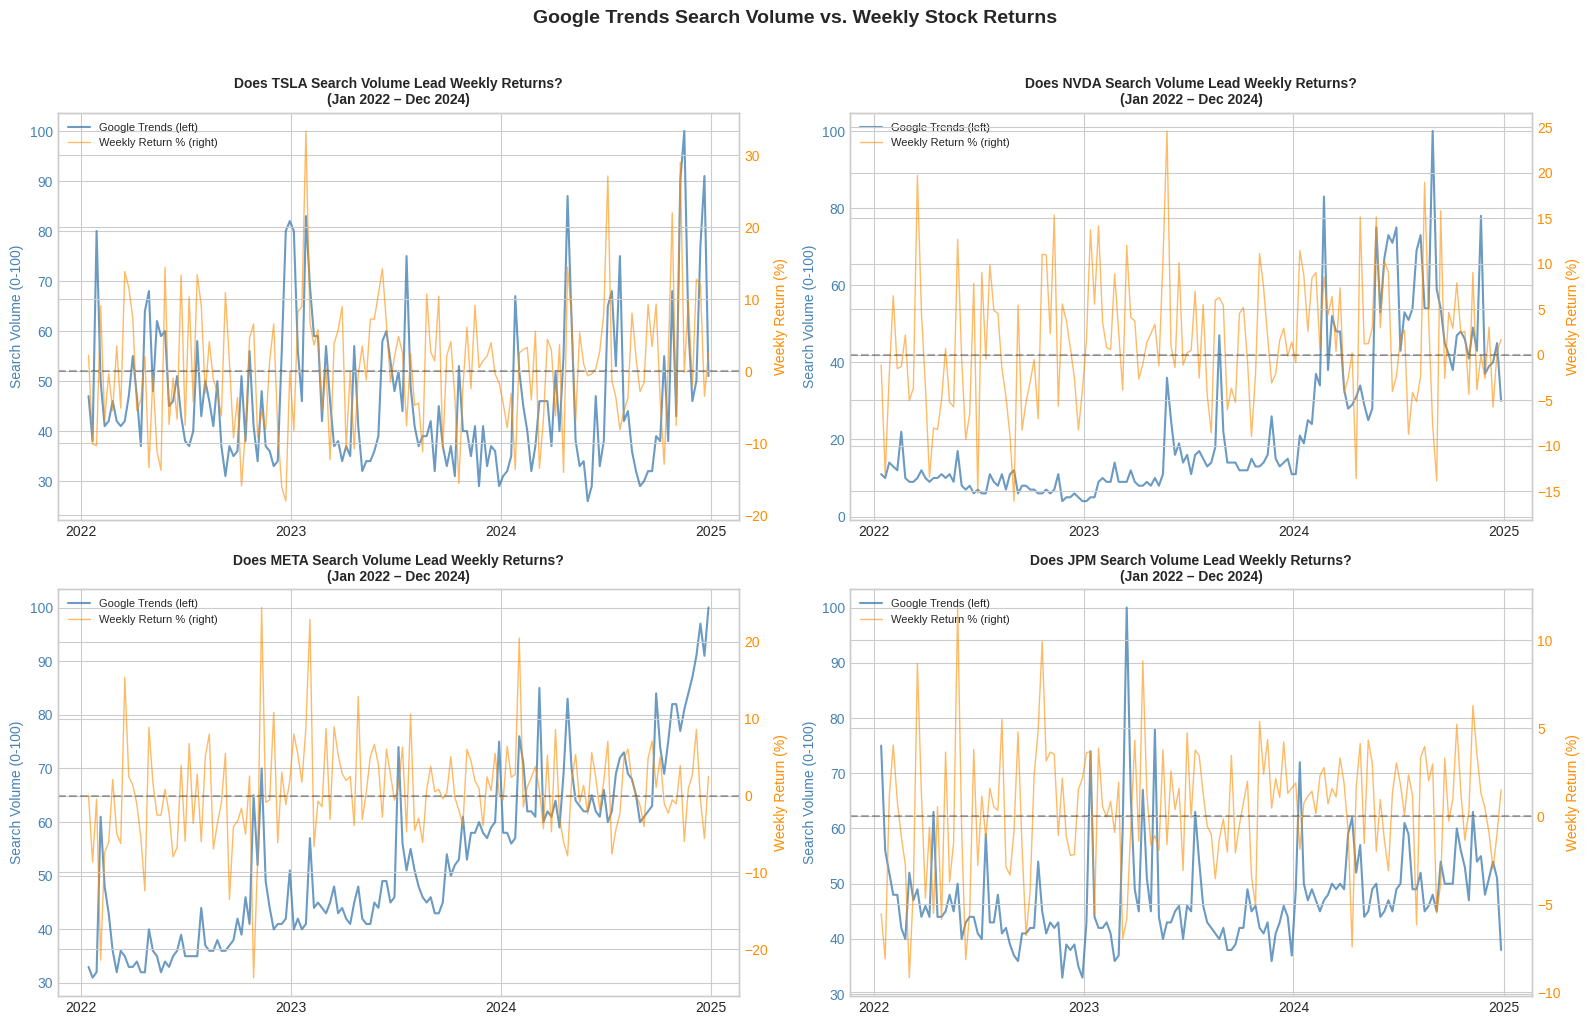

Saved: time_series_all_stocks.png

Generating Lag Correlation Chart


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

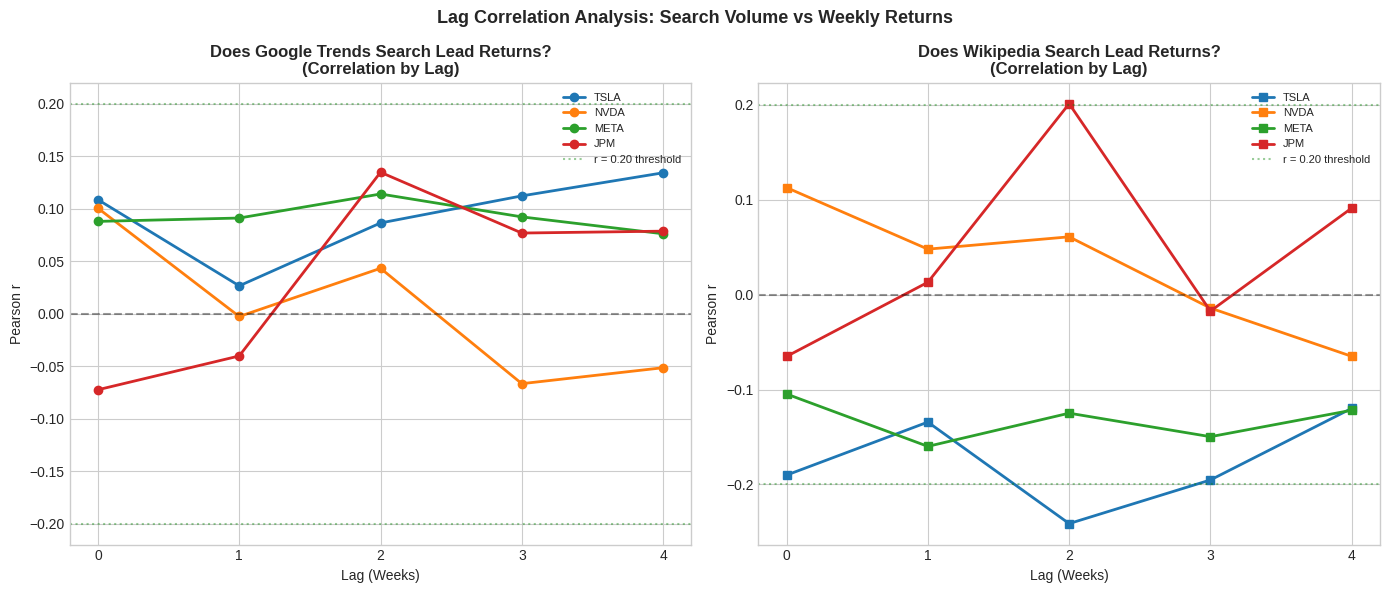

Saved: lag_correlation_chart.png

Generating Proxy Comparison Chart


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

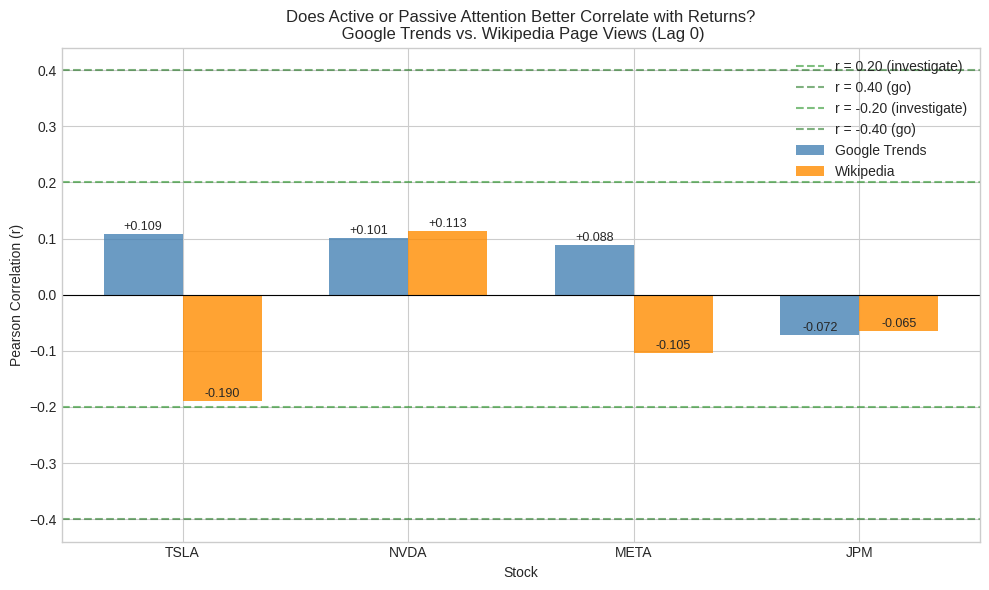

Saved: proxy_comparison_chart.png


In [10]:
#Section 7: Visualisations
#(1) Time Series Per Stock, (2) Lag Correlation, (3) Proxy Comparison

#Time Series Charts
print("Generating Time Series Charts")
fig, axes = plt.subplots(2,2,figsize=(16,10))
axes = axes.flatten()

for i, ticker in enumerate(TICKERS):
  ax1 = axes[i]
  ax2 = ax1.twinx()

  trends_col = f"{ticker}_trends_lag0"
  return_col = f"{ticker}_return"

  if trends_col in df_aligned.columns and return_col in df_aligned.columns:
    line1 = ax1.plot(df_aligned.index,
                     df_aligned[trends_col],
                     color = 'steelblue', alpha = 0.8,
                     label = "Google Trends (left)", linewidth = 1.5)
    line2 = ax2.plot(df_aligned.index,
                     df_aligned[return_col],
                     color = 'darkorange', alpha = 0.6,
                     label = 'Weekly Return % (right)', linewidth = 1)
    ax2.axhline(y = 0, color = 'black', linestyle = '--', alpha = 0.3)

    ax1.set_title(f'Does {ticker} Search Volume Lead Weekly Returns?\n'
                      f'(Jan 2022 – Dec 2024)',
                      fontsize=10, fontweight='bold')

    ax1.set_ylabel('Search Volume (0-100)', color = 'steelblue')
    ax2.set_ylabel('Weekly Return (%)', color = 'darkorange')
    ax1.tick_params(axis = 'y', labelcolor = 'steelblue')
    ax2.tick_params(axis = 'y', labelcolor = 'darkorange')

    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc = 'upper left', fontsize = 8)

    ax1.xaxis.set_major_locator(mdates.YearLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('Google Trends Search Volume vs. Weekly Stock Returns', fontsize = 14, fontweight = 'bold', y = 1.02)
plt.tight_layout()
plt.savefig('time_series_all_stocks.png', dpi = 150, bbox_inches = 'tight')
if IN_COLAB: files.download('time_series_all_stocks.png')
plt.show()
print("Saved: time_series_all_stocks.png")

#Lag Correlation
print("\nGenerating Lag Correlation Chart")

fig,(ax1,ax2) = plt.subplots(1,2,figsize = (14,6))

for ticker in TICKERS:
  if lag_results[ticker]['trends']:
    lags = list(lag_results[ticker]['trends'].keys())
    r_values = list(lag_results[ticker]['trends'].values())
    ax1.plot(lags, r_values, marker = 'o', label = ticker, linewidth = 2)

  if lag_results[ticker]['wiki']:
    lags = list(lag_results[ticker]['wiki'].keys())
    r_values = list(lag_results[ticker]['wiki'].values())
    ax2.plot(lags, r_values, marker = 's', label = ticker, linewidth = 2)

for ax, proxy in [(ax1,'Google Trends'), (ax2, 'Wikipedia')]:
  ax.axhline(y=0, color='black', linestyle = '--', alpha = 0.4)
  ax.axhline(y = 0.20, color = 'green', linestyle = ':', alpha = 0.4, label = 'r = 0.20 threshold')
  ax.axhline(y = -0.20, color = 'green', linestyle = ':', alpha = 0.4)
  ax.set_xlabel('Lag (Weeks)')
  ax.set_ylabel('Pearson r')
  ax.set_title(f'Does {proxy} Search Lead Returns?\n(Correlation by Lag)', fontweight = 'bold')
  ax.legend(fontsize = 8)
  ax.set_xticks(list(LAG_RANGE))

plt.suptitle('Lag Correlation Analysis: Search Volume vs Weekly Returns', fontsize = 13, fontweight = 'bold')
plt.tight_layout()
plt.savefig('lag_correlation_chart.png', dpi = 150, bbox_inches = 'tight')
if IN_COLAB: files.download('lag_correlation_chart.png')
plt.show()
print("Saved: lag_correlation_chart.png")

#Proxy Comparison
print("\nGenerating Proxy Comparison Chart")

fig, ax = plt.subplots(figsize=(10,6))
x = np.arange(len(TICKERS))
width = 0.35

trends_r_vals = [trends_corr_result.get(t, {}).get('pearson_r', 0) for t in TICKERS]
wiki_r_vals = [wiki_corr_results.get(t,{}).get('pearson_r', 0) for t in TICKERS]

bars1 = ax.bar(x - width/2, trends_r_vals, width, label = 'Google Trends', color = 'steelblue', alpha = 0.8)
bars2 = ax.bar(x + width/2, wiki_r_vals, width, label = 'Wikipedia', color = 'darkorange', alpha = 0.8)

for bar in bars1 + bars2:
  height = bar.get_height()
  ax.annotate(f'{height:+.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', fontsize=9)

ax.axhline(y = 0.20, color = 'green', linestyle = '--', alpha = 0.5, label = 'r = 0.20 (investigate)')
ax.axhline(y = 0.40, color = 'darkgreen', linestyle = '--', alpha = 0.5, label = 'r = 0.40 (go)')
ax.axhline(y = -0.20, color = 'green', linestyle = '--', alpha = 0.5, label = 'r = -0.20 (investigate)')
ax.axhline(y = -0.40, color = 'darkgreen', linestyle = '--', alpha = 0.5, label = 'r = -0.40 (go)')
ax.axhline(y = 0, color = 'black', linewidth = 0.8)

ax.set_xlabel('Stock')
ax.set_ylabel('Pearson Correlation (r)')
ax.set_title("Does Active or Passive Attention Better Correlate with Returns?\n Google Trends vs. Wikipedia Page Views (Lag 0)")
ax.set_xticks(x)
ax.set_xticklabels(TICKERS)
ax.legend()

plt.tight_layout()
plt.savefig('proxy_comparison_chart.png', dpi = 150, bbox_inches = 'tight')
if IN_COLAB: files.download('proxy_comparison_chart.png')
plt.show()
print("Saved: proxy_comparison_chart.png")



## Section 8: Findings

Results: **All eight tests are a no-go.** The null is the finding as publicly available attention data doesn't reliably precede price movement for these companies over this period.

**What the exploratory lags show.** Two of the 40 correlations cross 0.20: TSLA (Wiki) at lag 2 (−0.2413) and JPM (Wiki) at lag 2 (+0.2013). That's exactly what chance produces across 40 tests (40 × 0.05 = 2), they run in opposite directions, and nothing explains both. Noise, in other words is the reason lag 1 was fixed up front.

**What the proxies show.** On TSLA and META, Trends stays positive across every lag and Wikipedia stays negative across every lag with 20 correlations, 10 each way. NVDA and JPM don't hold any pattern. It changes no recommendation since everything sits below the bar, but it's the one stable thing in the data, and it says search and page views aren't measuring the same behaviour. That's the case for running two proxies instead of one.

*Per stock notes explain why each result is weak (ex. event driven timing for TSLA, a shared drive through AI for NVDA, expected weakness from JPM as an institutional stock).*

In [11]:
#Section 8: Findings
#r Threshold Validation
print("Tiered Recommendation Framework")

def apply_tiered_recommendation(r_value, ticker, proxy):
  abs_r = abs(r_value)
  if abs_r < 0.20:
    recommendation = "no-go"
    rationale = f"Correlation too weak (r = {r_value:+.4f}) to justify further investment."
  elif abs_r < 0.40:
    recommendation = "investigate"
    rationale = f"Moderate correlation (r = {r_value:+.4f}) warrants a pilot phase with backtesting."
  else:
    recommendation = "go"
    rationale = f"Stronger correlation (r = {r_value:+.4f}) warrants inclusion in signal development pipeline."

  confound = ""
  if ticker == 'TSLA':
    confound = ("""
    Caveat: TSLA experiences frequent event driven attention spikes tied to Elon Musk's personal news.
    These tend to produce same week co-movements, rather than a lead relationship. The search spike and
    price move occur in the same weekly aggreegate. A Lag 1 signal would be difficult to distinguish
    from multi week event tail effects.
    """)
  elif ticker == 'NVDA':
    confound = ("""
    Caveat: NVDA search volume and returns were both elevated during the same AI narrative periods ('23 to '24).
    This creates same week co-movements driven by a shared external factor rather than a relationship. A lag 1
    signal would be difficult to attribute to" "attention leading price versus both reacting simultaneously to AI
    news cycle
    """)
  elif ticker == 'JPM':
    confound = ("""
    Note: JPM weak correlation is the expected result for an institutionally traded stock. It is consistent with
    the project's contrast hypothesis, which states if the attention effect is retail-driven, JPM should be weaker.
    """)

  return recommendation, rationale + confound

#Tiered Recommendation Table
print("\nTiered Recommendation: Google Trends Proxy")
findings_rows = []
primary_lag = 1

for ticker in TICKERS:
    trends_lags = lag_results[ticker]['trends']        # 's' added — must match usage below
    if primary_lag in trends_lags:
        primary_r = trends_lags[primary_lag]
    elif ticker in trends_corr_result:                 # no 's' — matches Phase 5 variable
        primary_r = trends_corr_result[ticker]['pearson_r']
    else:
        continue

    if trends_lags:
        explor_lag = max(trends_lags, key=lambda k: abs(trends_lags[k]))
        explor_r = trends_lags[explor_lag]
    else:
        explor_lag, explor_r = primary_lag, primary_r

    rec, rationale = apply_tiered_recommendation(primary_r, ticker, 'trends')
    print(f"{ticker}")
    print(f"  Primary r (pre-registered lag {primary_lag}): {primary_r:+.4f}")
    print(f"  Recommendation (from lag {primary_lag}): {rec.upper()}")
    print(f"  {rationale}\n")

    findings_rows.append({
        'ticker': ticker,
        'proxy': 'Google Trends',
        'primary_lag_weeks': primary_lag,
        'primary_r': primary_r,
        'best_exploratory_lag': explor_lag,
        'best_exploratory_r': explor_r,
        'recommendation': rec
    })


print("\nTiered Recommendation: Wikipedia Proxy")

for ticker in TICKERS:
    wiki_lags = lag_results[ticker]['wiki']
    if primary_lag in wiki_lags:
        primary_r = wiki_lags[primary_lag]
    elif ticker in wiki_corr_results:
        primary_r = wiki_corr_results[ticker]['pearson_r']
    else:
        continue

    if wiki_lags:
        explor_lag = max(wiki_lags, key=lambda k: abs(wiki_lags[k]))
        explor_r = wiki_lags[explor_lag]
    else:
        explor_lag, explor_r = primary_lag, primary_r

    rec, rationale = apply_tiered_recommendation(primary_r, ticker, 'wiki')
    print(f"{ticker}")                                 # per-ticker print added
    print(f"  Primary r (pre-registered lag {primary_lag}): {primary_r:+.4f}")
    print(f"  Recommendation (from lag {primary_lag}): {rec.upper()}")
    print(f"  {rationale}\n")

    findings_rows.append({
        'ticker': ticker,
        'proxy': 'Wikipedia',
        'primary_lag_weeks': primary_lag,
        'primary_r': primary_r,
        'best_exploratory_lag': explor_lag,
        'best_exploratory_r': explor_r,
        'recommendation': rec
    })

findings_df = pd.DataFrame(findings_rows)
print("\nFinal Recommendation Table")
print(findings_df.to_string(index=False))

findings_df.to_csv('findings.csv', index=False)
df_aligned.to_csv('data_aligned.csv')
if IN_COLAB: files.download('findings.csv')
if IN_COLAB: files.download('data_aligned.csv')
print("\nfindings.csv and data_aligned.csv saved.")

#Null Result Path
all_weak = all(abs(row['primary_r']) < 0.20 for _, row in findings_df.iterrows())
if all_weak:
  print("""
  Null Result Statement: Trends and Wiki page views do not show a consistent lead relationship with
  weekly price movements for the four stocks analysed (TSLA, NVDA, META, JPM) over the Jan '22 to Dec
  '24 period. All correlation coefficients at the pre-registered lag (1) fall below the r = 0.2
  threshold required to jutify further signal development. Indicating that publicly available
  attention data does not reliably precede price movements for these stocks in this period.
  """)
else:
  print("\nMixed Results. Null result statement applies to 'no go' stocks only")
  print("See findings table for stock by stock recommendations")


Tiered Recommendation Framework

Tiered Recommendation: Google Trends Proxy
TSLA
  Primary r (pre-registered lag 1): +0.0265
  Recommendation (from lag 1): NO-GO
  Correlation too weak (r = +0.0265) to justify further investment.
    Caveat: TSLA experiences frequent event driven attention spikes tied to Elon Musk's personal news.
    These tend to produce same week co-movements, rather than a lead relationship. The search spike and
    price move occur in the same weekly aggreegate. A Lag 1 signal would be difficult to distinguish
    from multi week event tail effects.
    

NVDA
  Primary r (pre-registered lag 1): -0.0027
  Recommendation (from lag 1): NO-GO
  Correlation too weak (r = -0.0027) to justify further investment.
    Caveat: NVDA search volume and returns were both elevated during the same AI narrative periods ('23 to '24).
    This creates same week co-movements driven by a shared external factor rather than a relationship. A lag 1
    signal would be difficult to attri

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


findings.csv and data_aligned.csv saved.

  Null Result Statement: Trends and Wiki page views do not show a consistent lead relationship with
  weekly price movements for the four stocks analysed (TSLA, NVDA, META, JPM) over the Jan '22 to Dec
  '24 period. All correlation coefficients at the pre-registered lag (1) fall below the r = 0.2
  threshold required to jutify further signal development. Indicating that publicly available
  attention data does not reliably precede price movements for these stocks in this period.
  
